# Factores de Comportamiento del Cliente Asociados al Ingreso Anual — NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt


### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `visitas_mes`
- `compras_mes`
- `nivel_ingreso`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.
La columna `edad` tiene que corregirse con numeros enteros.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.select_dtypes('number').describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000



Diagnóstico inicial de variables numéricas

- `edad` — El rango de edad esta amplio teniendo en cuenta que la edad maxima es de 75 años de edad
- `nivel_ingreso` - El rango es demasiado amplio. La desviacion estandar esta muy alta comparada a la media.
- `visitas_mes` - Hay mucha concentracion de clientes (+50%) que tiene una visita entre 8-12 veces al mes.
- `compras_mes` - Cerca de la cuarta parte de los cliente no hace una compra.
- `gasto_publicidad_dirigida` - Hay clientes que no implicaron un gasto de publicidad dirigida.
- `satisfaccion` - Tiene una media positiva por encima de 3.6 de 5.
- `miembro_premium` y `abandono` - son booleanos. Aproximadamente 14% de los clientes son premium y poco mas del 15% de los clientes abandonan.
- `ingreso_anual` - Aproximadamente la cuarta parte de los datos son faltantes o mal registrados.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
df.select_dtypes('int64').nunique()

edad               58
visitas_mes        25
compras_mes         9
miembro_premium     2
abandono            2
dtype: int64


Diagnóstico inicial de variables binarias

- `miembro_premium` — Binario confirmado
- `abandono` — Binario confirmado

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
df.select_dtypes('object').nunique()

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print(df['tipo_dispositivo'].value_counts())
print(df['region'].value_counts())

móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64



Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — El cliente utiliza el movil mayoritariamente. Menos del 10% de los clientes utiliza tablet.
- `region` - La mayoria de los clientes son de la region norte del pais y la region este es la que tiene menos clientes.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

<AxesSubplot:>

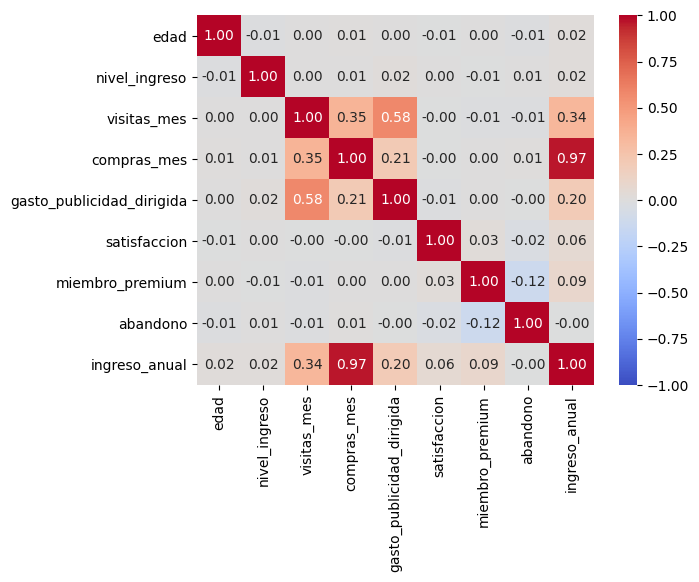

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr_matrix = df.select_dtypes('number').corr()
sb.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)



Observaciones generales (Heatmap)  
- Se observa que no hay practicamente relacion entre las variables `edad`, `nivel_ingreso`, `satisfaccion`, `miembro_premium` y `abandono`.


Observaciones respecto a `ingreso_anual`  
- Presenta una correlacion fuerte con `compras_mes`.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - # Decidi no incluir un scatterplot general porque el heatmap no presenta una relacion entre si en la mayoria de las variables. Es mas eficiente ir directo al par clave que mostro mas correlacion. 

### Scatterplot para pares clave

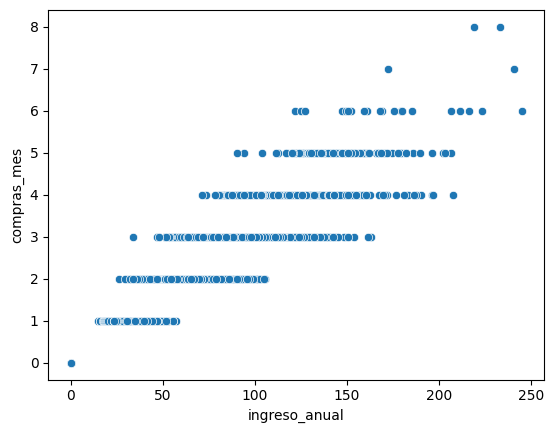

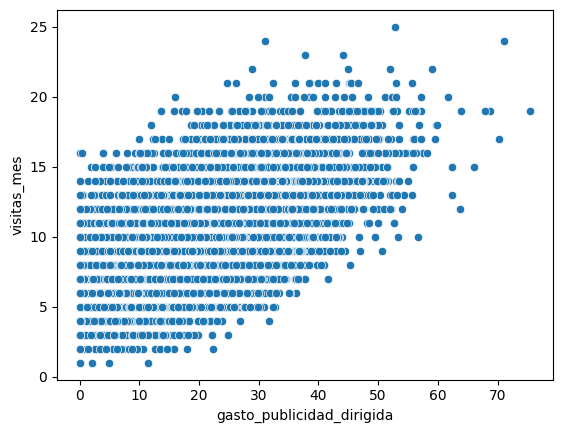

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sb.scatterplot(data=df, x='ingreso_anual', y='compras_mes')
plt.show()

sb.scatterplot(data=df, x='gasto_publicidad_dirigida', y='visitas_mes')
plt.show()




Observaciones iniciales (Scatterplot)

**ingreso_anual vs compras_mes**
- Dirección positiva
- Dispersión baja
- Hay presencia de outliers
- Correlación fuerte

**gasto_publicidad_dirigida vs visitas_mes**
- Dirección positiva
- Dispersión baja
- Hay presencia de outliers
- Correlación moderada

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
df['ingreso_anual'].corr(df['compras_mes'], method='pearson')

0.9671485435708566

In [ ]:
# Calcular correlación entre variables relevantes
df['gasto_publicidad_dirigida'].corr(df['visitas_mes'], method='spearman')

0.5592673242622609



Observaciones de correlación

**ingreso_anual vs compras_mes**
- Dirección positiva
- Correlación fuerte
- Magnitud alta

**gasto_publicidad_dirigida vs visitas_mes**
- Dirección positiva
- Correlación moderada
- Magnitud media

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

pointbiserialr(df['miembro_premium'], df['ingreso_anual'])

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)


Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación baja
- Dirección positiva

### V de Cramér

In [ ]:
from scipy.stats import chi2_contingency

# Función para calcular V de Cramér
def cramers(var1, var2):
    # pasos internos
    tabla = pd.crosstab(var1, var2)
    n = tabla.sum().sum() 
    k = min(tabla.shape)
    chi2, _, _, _ = chi2_contingency(tabla)
    resultado = np.sqrt(chi2 / (n * (k - 1)))
    
    return resultado

In [ ]:
# Aplicar V de Cramér en variables relevantes
cramers(df['tipo_dispositivo'], df['region'])


0.012378338407739397


**Observaciones V de Cramér**
Con un valor de 0.012 nos indica que hay una asociación muy baja entre el tipo de dispositivo y la region geográfica del cliente



## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio
---


### Hallazgo 1 — Asociación entre `compras_mes` vs `ingreso_anual`


**Evidencia visual**

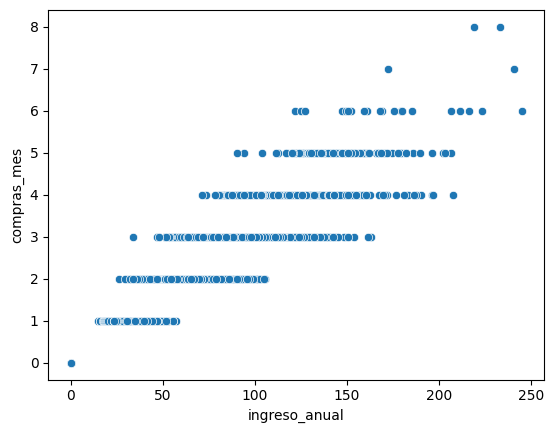

In [ ]:
sb.scatterplot(data=df, x='ingreso_anual', y='compras_mes')
plt.show()

**Evidencia numérica:** 

In [ ]:
df['ingreso_anual'].corr(df['compras_mes'], method='pearson')

0.9671485435708566

"Aplicando el método Pearson se puede asociar que a medida que hay mas compras en el mes, el ingreso anual tiende a incrementar. Debido a esto, se recomienda explorar los clientes con compras altas para ofrecer programas de fidelidad o campañas para la captacion de clientes y asi poder mantener un porcentaje de retencion de clientes alto."

### Hallazgo 2 — No hay relacion entre `miembro_premium` vs `ingreso_anual`


In [ ]:
pointbiserialr(df['miembro_premium'], df['ingreso_anual'])

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

"Los clientes con membresía premium presentan una asociación baja con el ingreso anual, lo que sugiere que la membresía premium no está relacionada con el ingreso generado."

### Hallazgo 3 — Correlación moderada positiva entre `gasto_publicidad_dirigida` vs `visitas_mes`


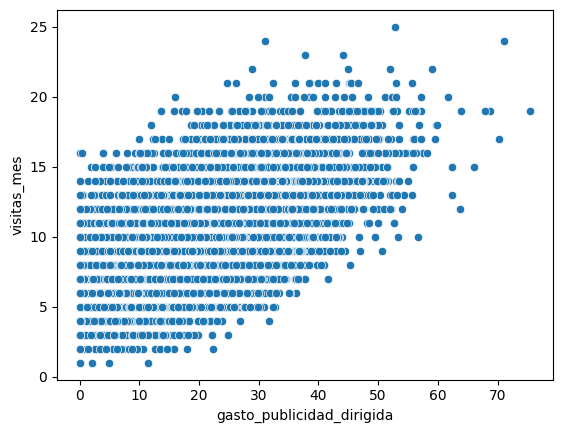

In [ ]:
sb.scatterplot(data=df, x='gasto_publicidad_dirigida', y='visitas_mes')
plt.show()

In [ ]:
df['gasto_publicidad_dirigida'].corr(df['visitas_mes'], method='spearman')

0.5592673242622609

"Con un coeficiente de 0.56 aplicando el método Spearman, podemos apreciar una relación positiva/moderada entre `gasto_publicidad_dirigida` y `visitas_mes` sin embargo no necesariamente una variable causa a la otra. Hay que profundizar en las razones por las que cada variable aumentan."

### Hallazgo 4 — Asociación baja entre `tipo_dispositivo` vs `region`


In [ ]:
cramers(df['tipo_dispositivo'], df['region'])

0.012378338407739397

"El coeficiente resultante de 0.012 indica que no existe una asociacion entre ambas variables categoricas, sin embargo no podemos afirmar que ambas variables no esten relacionadas entre si. "

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Hay aproximadamente 25% de datos faltantes en ingreso_anual.
- Ausencia de datos relacionados a factores externos(competencia, campañas especificas, estacionalidad)
- Dataset incompleto. Solo incluye cierre del 2024.

### **Próximos pasos** 

Buscar relación por metodo Spearman
- `abandono` vs `ingreso_anual`
- `satisfaccion` vs `ingreso_anual`
- `visitas_mes` vs `ingreso_anual`

Profundizar en datos faltantes
- `ingreso_anual`

Validar relaciones y no-relaciones encontradas
- `compras_mes` vs `ingreso_anual`
- `miembro_premium` vs `ingreso_anual`
- `gasto_publicidad_dirigida` vs `visitas_mes`
- `tipo_dispositivo` vs `region`